<a href="https://colab.research.google.com/github/sn-kc/AI-ML-CLASS/blob/main/face_reconstruction_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Libraries

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people # fetch meaning loading another phase which use for loading
from sklearn.decomposition import PCA as RandomizedPCA
from PIL import Image


# loading faces dataset

In [4]:
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


# Train PCA

In [5]:
pca = RandomizedPCA(600)
pca.fit(faces.data)

PCA(n_components=600)

# Read and preprocess  image

In [8]:
raw_img = Image.open("face.png").convert("L")
resized_img = raw_img.resize((47, 62))
pixel_matrix = np.array(resized_img)

# Flatten image

In [9]:
flat_face = pixel_matrix.reshape(1, 47 * 62)

# reconstruction

In [15]:
components = pca.transform(flat_face)
reconstructed_matrix = pca.inverse_transform(components)

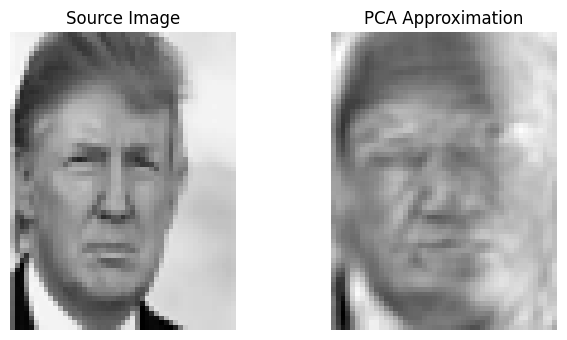

In [20]:
# Plot the results
plt.figure(figsize=(7, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(pixel_matrix, cmap="gray")
plt.title("Source Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_matrix, cmap="gray")
plt.title("PCA Approximation")
plt.axis("off")

plt.tight_layout()
plt.show()